# Strands Agents with Bedrock AgentCore Browser

This workshop demonstrates how to integrate Strands Agents with Amazon Bedrock AgentCore Browser to create AI agents capable of interacting with web browsers dynamically.

## Overview

In this lab, you will:

- Learn about Bedrock AgentCore Browser capabilities
- Test browser automation with Strands Agents
- Navigate websites and extract information programmatically
- Explore common use cases for browser automation
- Understand best practices for web interaction


## Prerequisites

Before starting this lab, ensure you have:

- AWS credentials configured (IAM role or environment variables)
- Required Python packages installed
- Nova Pro model ID based on AWS region

If you're not running in an environment with an IAM role assumed, set your AWS credentials as environment variables:


In [1]:
# %env AWS_REGION=<Bedrock AgentCore Region>
# %env AWS_ACCESS_KEY_ID=<YOUR ACCESS KEY>
# %env AWS_SECRET_ACCESS_KEY=<YOUR SECRET KEY>
# %env AWS_SESSION_TOKEN=<OPTIONAL - YOUR SESSION TOKEN IF TEMP CREDENTIAL>
# %env AWS_PROFILE=<OPTIONAL - Your profile configured in ~/.aws/config>

Install required packages for Strands Agents, Playwright and Bedrock AgentCore Python SDK:


In [2]:
#%pip install -q strands-agents 'strands-agents-tools[agent_core_browser]' bedrock-agentcore playwright rich

Setup Nova Pro model ID based on AWS region:

In [3]:
import boto3

region = boto3.session.Session().region_name

NOVA_PRO_MODEL_ID = "us.amazon.nova-pro-v1:0"
if region.startswith("eu"):
    NOVA_PRO_MODEL_ID = "eu.amazon.nova-pro-v1:0"
elif region.startswith("ap"):
    NOVA_PRO_MODEL_ID = "apac.amazon.nova-pro-v1:0"

print(f"Nova Pro Model ID: {NOVA_PRO_MODEL_ID}")

Nova Pro Model ID: us.amazon.nova-pro-v1:0


## What is Bedrock AgentCore Browser?

Amazon Bedrock AgentCore Browser is a powerful tool that enables AI agents to interact with web browsers dynamically in a secure, managed environment. Key capabilities include:

- **Web Navigation**: Navigate to websites, click elements, and fill forms programmatically
- **Content Extraction**: Extract information from web pages and capture screenshots
- **Secure Environment**: Runs in an isolated, secure browser environment
- **JavaScript Execution**: Execute custom JavaScript for advanced web interactions
- **Session Management**: Maintain browser sessions across multiple operations

The Browser tool enables agents to perform complex web-based tasks that require visual understanding and interactive capabilities.


### Accessing Browser Session

First let's explore the AgentCore Browser tool without any agentic environment.  We will use the Playwright library to connect to the remote browser session.

Once connected, we can start interacting with the page elements as if it's a real user.  


🌐 Using AgentCore Browser Session: 01KKQ16CZT0TNTXFWW1E33X3FN

✅ Browser connected.

🔄 Navigating to AWS Builder Center

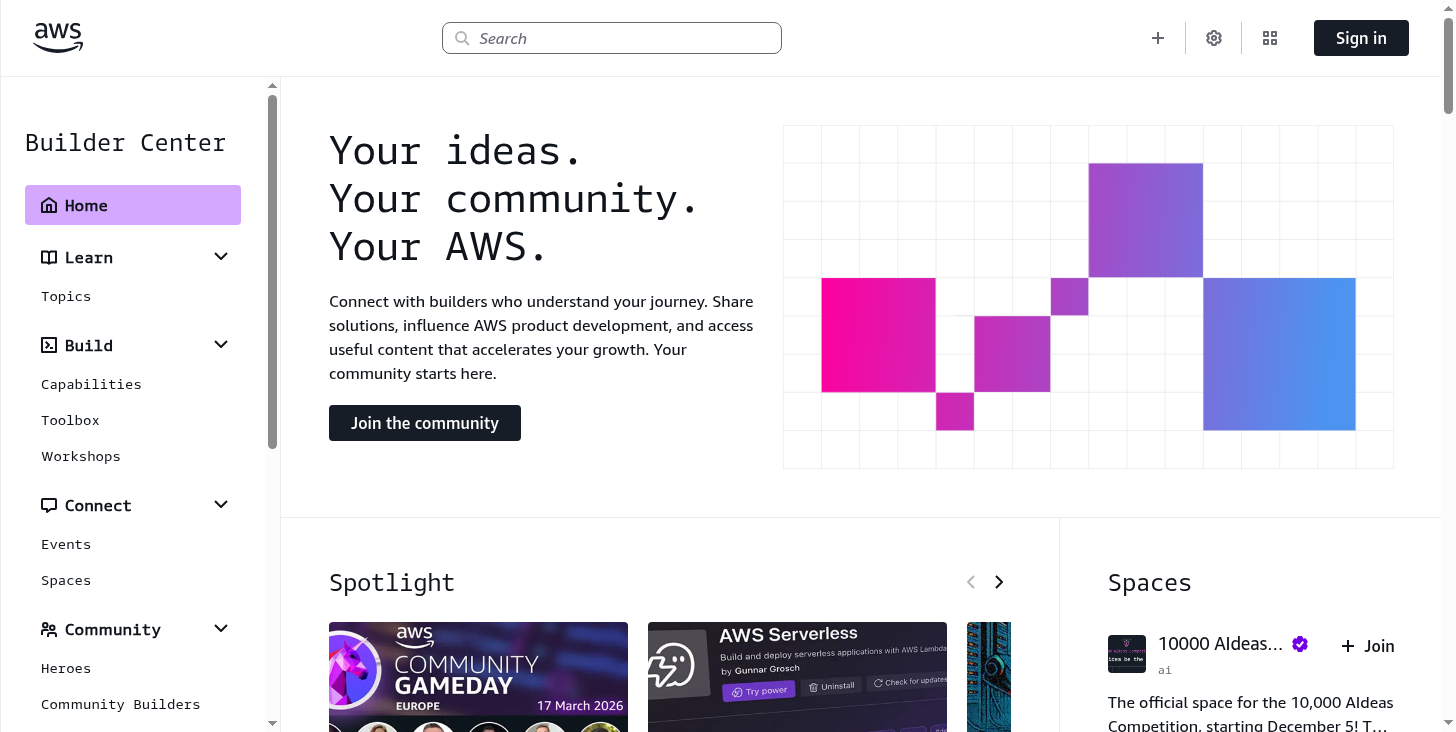

🔄 Clicking on the first article in the spotlight

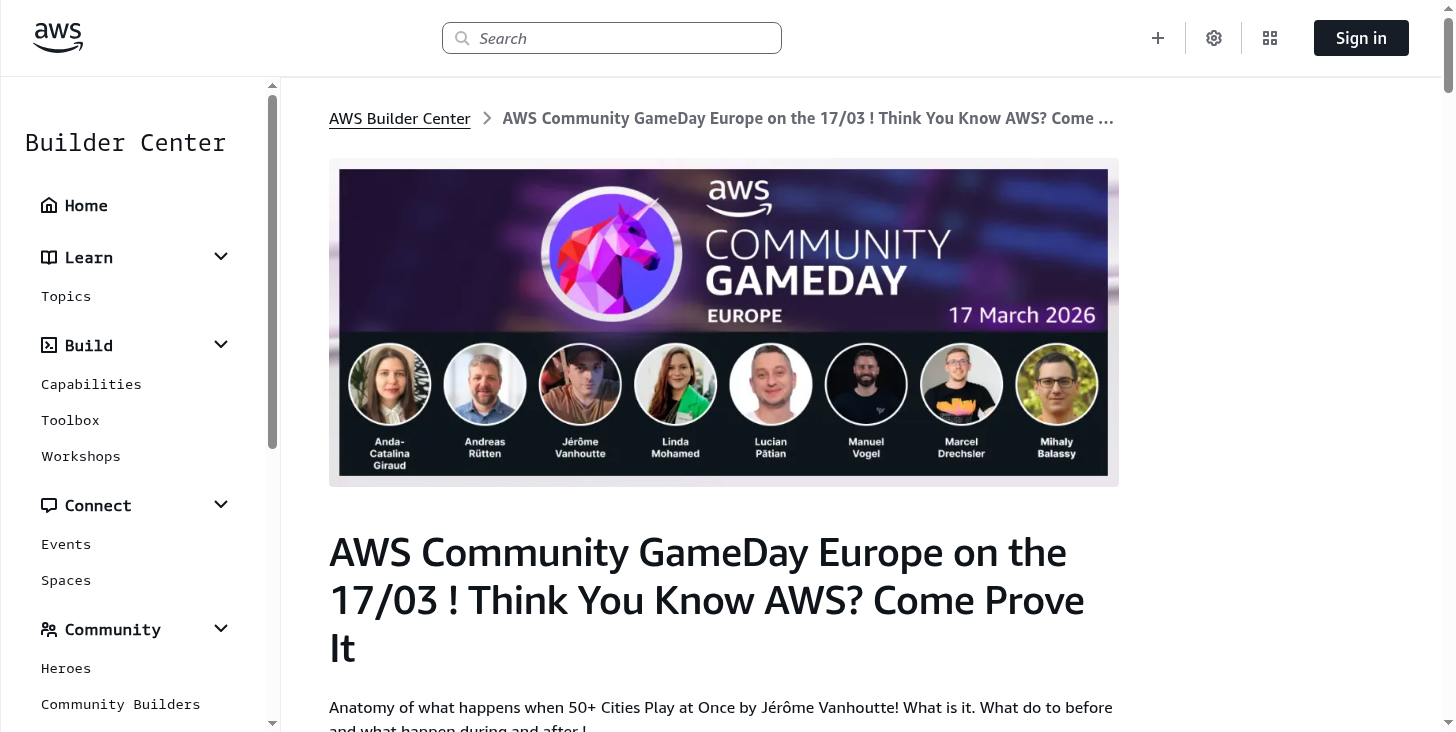

In [4]:
import boto3
import rich
from bedrock_agentcore.tools.browser_client import browser_session
from playwright.async_api import async_playwright
from IPython.display import display_jpeg

console = rich.get_console()
region = boto3.Session().region_name or "us-east-1"

with browser_session(region) as client:
    console.print(f"🌐 Using AgentCore Browser Session: {client.session_id}", style="cyan")
    ws_url, headers = client.generate_ws_headers()

    async with async_playwright() as playwright:
        chromium = playwright.chromium
        browser = await chromium.connect_over_cdp(endpoint_url=ws_url, headers=headers)
        console.print("[green]✅ Browser connected.[/green]")

        context = browser.contexts[0] if browser.contexts else await browser.new_context()
        page = context.pages[0] if context.pages else await context.new_page()

        console.print("[cyan]🔄 Navigating to AWS Builder Center[/cyan]")
        await page.goto("https://builder.aws.com/")
        await page.wait_for_timeout(5000)
        display_jpeg(await page.screenshot(), raw=True)

        console.print("[cyan]🔄 Clicking on the first article in the spotlight[/cyan]")
        await page.click(".swiper-wrapper div a")
        await page.wait_for_timeout(5000)
        display_jpeg(await page.screenshot(), raw=True)


### Testing Strands Agent with Browser Automation

Let's demonstrate the Strands Agent using AgentCore Browser for web automation. We'll navigate to Amazon, search for coffee makers, and extract detailed product information from the first result.


In [5]:
import boto3
import rich
from strands import Agent
from strands.models import BedrockModel
from strands_tools.browser import AgentCoreBrowser


console = rich.get_console()
region = boto3.Session().region_name or "us-east-1"

agentcore_browser = AgentCoreBrowser(region=region)

agent = Agent(
    model=BedrockModel(model_id=NOVA_PRO_MODEL_ID),
    tools=[agentcore_browser.browser],
)

response = await agent.invoke_async("Go to https://builder.aws.com/learn/topics/amazon-bedrock-agentcore, once the page has loaded find the first link that goes to path starting with '/content' and click on it, once the page has loaded, retrieve the page html and summarize the article")

console.print(response.message["content"][0]["text"] if "text" in response.message["content"][0] else "")


<thinking> To complete this task, I need to follow these steps:
1. Initialize a browser session.
2. Navigate to the specified URL.
3. Wait for the page to load.
4. Find the first link that starts with '/content' and click on it.
5. Wait for the new page to load.
6. Retrieve the HTML content of the new page.
7. Summarize the article based on the HTML content.

Let's start by initializing a browser session and navigating to the URL. </thinking>

Tool #1: browser
<thinking> The browser session has been initialized. The next step is to navigate to the specified URL. </thinking> 
Tool #2: browser
<thinking> The page has been navigated to. The next step is to find the first link that starts with '/content' and click on it. </thinking> 
Tool #3: browser
<thinking> The first link starting with '/content' has been clicked. The next step is to wait for the new page to load. </thinking> 
Tool #4: browser
<thinking> The HTML content of the new page has been retrieved. The next step is to summarize

<thinking> The HTML content of the new page has been retrieved. The next step is to summarize the article based on 
the HTML content. </thinking>

The article is about how Seth David Gyimah created an Amazon Nova powered AI moderation layer for his real estate 
app. The article provides insights into the process and the benefits of using Amazon Nova for AI moderation. The 
full content of the article can be found on the AWS Builder Center website.

Let's examine the detailed execution flow of the agent loop to understand how the agent processes requests and generates responses:


In [6]:
from rich.table import Table
import rich
import json

console = rich.get_console()

console.print("Agent Loop Detail")
console.rule()
console.print(f"Number of Loops: {agent.event_loop_metrics.cycle_count}")

table = Table(title="Agent Messages", show_lines=True)
table.add_column("Role", style="green")
table.add_column("Text", style="magenta")
table.add_column("Tool Name", style="cyan")
table.add_column("Tool Input", style="cyan")
table.add_column("Tool Result", style="cyan")

for message in agent.messages:
    text = [content["text"] for content in message["content"] if "text" in content]
    tool_name = [content["toolUse"]["name"] for content in message["content"] if "toolUse" in content]
    tool_input = [content["toolUse"]["input"] for content in message["content"] if "toolUse" in content]
    tool_result = [content["toolResult"]["content"][0] for content in message["content"] if "toolResult" in content]
    table.add_row(message["role"], text[-1] if text else "", 
                  tool_name[-1] if tool_name else "", 
                  json.dumps(tool_input[-1], indent=2) if tool_input else "", 
                  (json.dumps(tool_result[-1], indent=2)[:500]+"\n.\n.\n." if len(str(tool_result[-1])) > 500 else json.dumps(tool_result[-1], indent=2)) if tool_result else "")

console.print(table)

Agent Loop Detail

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Number of Loops: 5

                                                  Agent Messages                                                   
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Role      ┃ Text                        ┃ Tool Name ┃ Tool Input                  ┃ Tool Result                 ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user      │ Go to                       │           │                             │                             │
│           │ https://builder.aws.com/le… │           │                             │                             │
│           │ once the page has loaded    │           │                             │                             │
│           │ find the first link that    │           │                             │                             │
│           │ goes to path starting with  │           │                             │                             │
│           │ '/content' and click on it, │           │                             │                             │
│           │ once the page has loaded,   │           │                             │                             │
│           │ retrieve the page html and  │           │                             │                             │
│           │ summarize the article       │           │                             │                             │
├───────────┼─────────────────────────────┼───────────┼─────────────────────────────┼─────────────────────────────┤
│ assistant │ <thinking> To complete this │ browser   │ {                           │                             │
│           │ task, I need to follow      │           │   "browser_input": {        │                             │
│           │ these steps:                │           │     "action": {             │                             │
│           │ 1. Initialize a browser     │           │       "type":               │                             │
│           │ session.                    │           │ "init_session",             │                             │
│           │ 2. Navigate to the          │           │       "description":        │                             │
│           │ specified URL.              │           │ "Navigate to AWS Builder    │                             │
│           │ 3. Wait for the page to     │           │ and click on a content      │                             │
│           │ load.                       │           │ link",                      │                             │
│           │ 4. Find the first link that │           │       "session_name":       │                             │
│           │ starts with '/content' and  │           │ "aws-builder-session"       │                             │
│           │ click on it.                │           │     }                       │                             │
│           │ 5. Wait for the new page to │           │   }                         │                             │
│           │ load.                       │           │ }                           │                             │
│           │ 6. Retrieve the HTML        │           │                             │                             │
│           │ content of the new page.    │           │                             │                             │
│           │ 7. Summarize the article    │           │                             │                             │
│           │ based on the HTML content.  │           │                             │                             │
│           │                             │           │                             │                             │
│           │ Let's start by initializing │           │                             │                             │
│           │ a browser session and       │           │ 

### Cleanup Resources

In [7]:
client = boto3.client("bedrock-agentcore")

args = {"browserIdentifier": "aws.browser.v1", "status": "READY"}
while True:
    response = client.list_browser_sessions(**args)
    for session in response["items"]:
        client.stop_browser_session(
            browserIdentifier=args["browserIdentifier"], sessionId=session["sessionId"]
        )

    if "NextToken" in response:
        args["NextToken"] = response["NextToken"]
    else:
        break

## Common Use Cases for Bedrock AgentCore Browser

Beyond web search, Bedrock AgentCore Browser enables a wide variety of automation scenarios:

### Web Application Testing

- Test web applications in a secure environment
- Validate user interfaces and functionality
- Perform automated quality assurance

### Data Collection & Monitoring

- Extract information from websites
- Monitor website changes and updates
- Capture screenshots and record browser sessions

### Business Process Automation

- Automate form submissions and data entry
- Perform e-commerce transactions
- Access online resources and services

### AI-Powered Web Interaction

- Build AI agents that can navigate the web
- Interact with web interfaces intelligently
- Perform web-based tasks and workflows

**Additional Resources:**
[Bedrock AgentCore Browser Use Cases Examples](https://docs.aws.amazon.com/bedrock-agentcore/latest/devguide/browser-use-cases.html#browser-use-cases-examples)
